<a href="https://colab.research.google.com/github/diipperss/DNN_GroupProject/blob/main/PartA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PART A


---


## Dynamic Speech Emotion Recognition



---



In [1]:
pip install librosa torch numpy scikit-learn

In [2]:
import os
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
zip_path = "/content/drive/MyDrive/Y4/DNN/ravdess.zip"

In [6]:
import zipfile

extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
for root, dirs, files in os.walk("/content/data"):
    print(root)
    break

/content/data


In [9]:
#config
DATA_PATH = extract_path
SR = 22050
MAX_LEN = 200
BATCH_SIZE = 32
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTIONS = [
    "neutral","calm","happy","sad",
    "angry","fearful","disgust","surprised"
]

In [10]:
def load_data(root):
    files, labels = [], []

    for r, d, f_list in os.walk(root):
        for f in f_list:
            if f.endswith(".wav"):
                path = os.path.join(r, f)
                emotion = int(f.split("-")[2]) - 1
                files.append(path)
                labels.append(emotion)

    return files, labels

files, labels = load_data(DATA_PATH)

print("Total files:", len(files))

Total files: 2880


In [11]:
class SERDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def extract(self, path):
        y, sr = librosa.load(path, sr=SR)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        if mfcc.shape[1] < MAX_LEN:
            mfcc = np.pad(mfcc, ((0,0),(0,MAX_LEN-mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :MAX_LEN]

        return mfcc

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = self.extract(self.files[idx])
        y = self.labels[idx]

        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(0),
            torch.tensor(y, dtype=torch.long)
        )


In [12]:
#split
train_f, val_f, train_l, val_l = train_test_split(
    files, labels, test_size=0.2, random_state=42
)

train_loader = DataLoader(SERDataset(train_f, train_l), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SERDataset(val_f, val_l), batch_size=BATCH_SIZE)

In [13]:
#model
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*10*50,128),
            nn.ReLU(),
            nn.Linear(128,8)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = Model().to(DEVICE)

In [14]:
#train
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)

        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out,y)

        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")

Epoch 1/10 Loss: 647.8272
Epoch 2/10 Loss: 110.9763
Epoch 3/10 Loss: 64.0581
Epoch 4/10 Loss: 21.6702
Epoch 5/10 Loss: 4.8048
Epoch 6/10 Loss: 0.9434
Epoch 7/10 Loss: 0.2875
Epoch 8/10 Loss: 0.0972
Epoch 9/10 Loss: 0.0580
Epoch 10/10 Loss: 0.0423


In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#evaluation
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

acc = accuracy_score(y_true, y_pred)
print(f"\nValidation Accuracy: {acc:.4f}")


Validation Accuracy: 0.9062


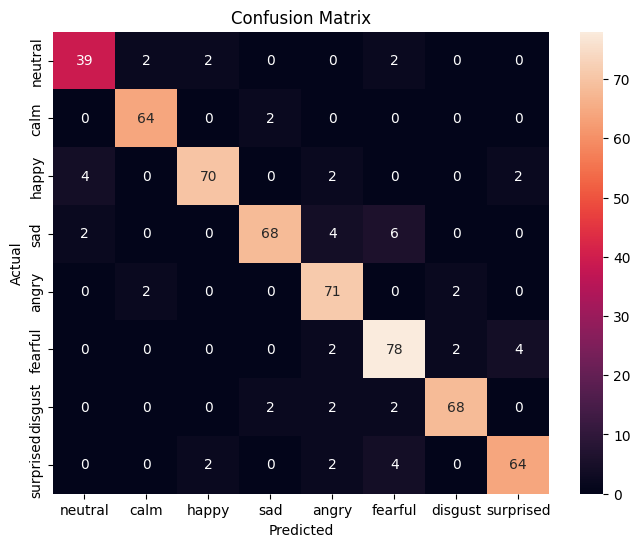

In [17]:
#confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTIONS,
            yticklabels=EMOTIONS)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()